TEST!!!!!!!

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


In [6]:
df = pd.read_excel("/Users/dheeraj/Downloads/Online_Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
print(df.shape)
df.info()
df.describe()
df.columns

(541909, 8)
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df.duplicated().sum()


5268

In [10]:
missing = df.isnull().sum()/len(df)*100

print(missing.sort_values(ascending=False))

CustomerID     24.926694
Description     0.268311
InvoiceNo       0.000000
StockCode       0.000000
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
Country         0.000000
dtype: float64


In [11]:
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [13]:
print(df['CustomerID'].nunique())
print(df['StockCode'].nunique())
print(df['InvoiceNo'].nunique())

4372
3684
22190


In [14]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [15]:
df[['Quantity','UnitPrice','Revenue']].head(5)

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


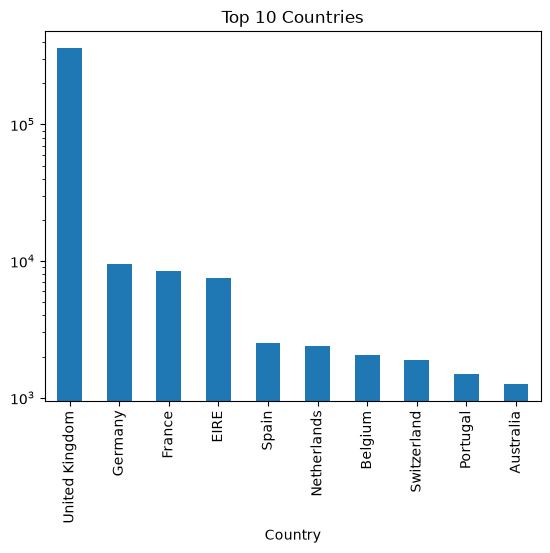

In [16]:
top_countries = df['Country'].value_counts().head(10)

top_countries.plot(kind='bar')

plt.title('Top 10 Countries')

plt.yscale("log")
plt.show()

In [17]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12


In [18]:
df['Month'].nunique()

13

In [19]:
monthly_sales = df.groupby('Month')['Revenue'].sum()
monthly_sales

Month
2010-12     554604.020
2011-01     475074.380
2011-02     436546.150
2011-03     579964.610
2011-04     426047.851
2011-05     648251.080
2011-06     608013.160
2011-07     574238.481
2011-08     616368.000
2011-09     931440.372
2011-10     974603.590
2011-11    1132407.740
2011-12     342506.380
Freq: M, Name: Revenue, dtype: float64

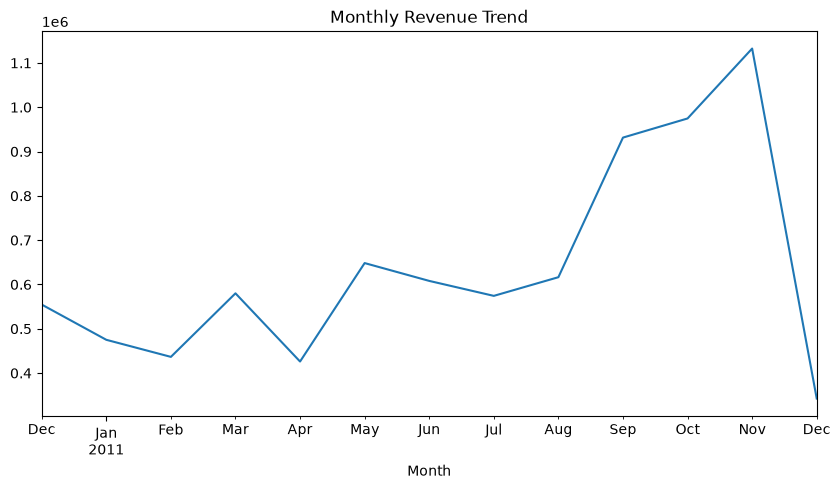

In [20]:
monthly_sales.plot(figsize=(10,5))

plt.title('Monthly Revenue Trend')

plt.show()

In [24]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]


In [25]:
df = df[df['Quantity'] > 0]


In [26]:
df = df[df['UnitPrice'] > 0]

In [27]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12


In [61]:
max_date = df['InvoiceDate'].max() + pd.Timedelta(days=0)

print(max_date)

2011-12-09 12:50:00


In [62]:
cutoff_date = pd.Timestamp('2011-09-01')

train_period = df[df['InvoiceDate'] < cutoff_date]

future_period = df[df['InvoiceDate'] >= cutoff_date]

In [63]:
print(train_period.shape)
print(future_period.shape)

(226467, 10)
(171417, 10)


In [64]:
train_period['Revenue'] = (
    train_period['Quantity']
    *
    train_period['UnitPrice']
)

In [66]:
snapshot_date = train_period['InvoiceDate'].max() + pd.Timedelta(days=1)
print(snapshot_date)

2011-09-01 17:16:00


In [67]:
recency = train_period.groupby(
    'CustomerID'
)['InvoiceDate'].max()

recency = (
    snapshot_date - recency
).dt.days

In [68]:
frequency = train_period.groupby(
    'CustomerID'
)['InvoiceNo'].nunique()

In [69]:
monetary = train_period.groupby(
    'CustomerID'
)['Revenue'].sum()

In [71]:
rfm = pd.DataFrame()

rfm['Recency'] = recency
rfm['Frequency'] = frequency
rfm['Monetary'] = monetary

rfm.reset_index(inplace=True)
print(rfm.head(5))

   CustomerID  Recency  Frequency  Monetary
0       12346      226          1  77183.60
1       12347       30          5   2790.86
2       12348      149          3   1487.24
3       12350      211          1    334.40
4       12352      163          5   1561.81


In [72]:
active_customers = future_period[
    'CustomerID'
].unique()

In [73]:
rfm['Churn'] = np.where(
    rfm['CustomerID'].isin(active_customers),
    0,
    1
)

In [74]:
print(rfm)

      CustomerID  Recency  Frequency  Monetary  Churn
0          12346      226          1  77183.60      1
1          12347       30          5   2790.86      0
2          12348      149          3   1487.24      0
3          12350      211          1    334.40      1
4          12352      163          5   1561.81      0
...          ...      ...        ...       ...    ...
3312       18280      178          1    180.60      1
3313       18281       81          1     80.82      1
3314       18282       27          1    100.21      0
3315       18283       49          9    985.77      0
3316       18287      102          1    765.28      0

[3317 rows x 5 columns]


In [75]:
rfm['Churn'].value_counts()

Churn
0    1952
1    1365
Name: count, dtype: int64

In [76]:
from sklearn.preprocessing import StandardScaler

features = rfm[
    ['Recency','Frequency','Monetary']
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [77]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm['Segment'] = kmeans.fit_predict(
    scaled_features
)

In [78]:
X = rfm[
    ['Recency',
     'Frequency',
     'Monetary']
]

y = rfm['Churn']

In [79]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [80]:
from sklearn.ensemble import RandomForestClassifier

rf_global = RandomForestClassifier(
    random_state=42
)

rf_global.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score
)

global_preds = rf_global.predict(X_test)

global_acc = accuracy_score(
    y_test,
    global_preds
)

global_f1 = f1_score(
    y_test,
    global_preds
)

global_auc = roc_auc_score(
    y_test,
    rf_global.predict_proba(X_test)[:,1]
)

print(global_acc)
print(global_f1)
print(global_auc)

0.6445783132530121
0.5461538461538461
0.7057184077644436


In [82]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

comparison_results = []

In [83]:
for segment in sorted(rfm['Segment'].unique()):

    segment_data = rfm[rfm['Segment'] == segment]

    # Skip tiny segments
    if len(segment_data) < 50:
        print(f"Skipping Segment {segment} - too few records")
        continue

    X_seg = segment_data[
        ['Recency','Frequency','Monetary']
    ]

    y_seg = segment_data['Churn']

    # Need both classes present
    if y_seg.nunique() < 2:
        print(f"Skipping Segment {segment} - only one churn class")
        continue

    X_train_seg, X_test_seg, y_train_seg, y_test_seg = train_test_split(
        X_seg,
        y_seg,
        test_size=0.2,
        random_state=42,
        stratify=y_seg
    )

    rf_seg = RandomForestClassifier(
        random_state=42
    )

    rf_seg.fit(X_train_seg, y_train_seg)

    preds_seg = rf_seg.predict(X_test_seg)

    seg_acc = accuracy_score(
        y_test_seg,
        preds_seg
    )

    seg_f1 = f1_score(
        y_test_seg,
        preds_seg
    )

    seg_auc = roc_auc_score(
        y_test_seg,
        rf_seg.predict_proba(X_test_seg)[:,1]
    )

    comparison_results.append([
        segment,
        global_acc,
        seg_acc,
        global_f1,
        seg_f1,
        global_auc,
        seg_auc
    ])

Skipping Segment 3 - too few records


In [84]:
comparison_df = pd.DataFrame(
    comparison_results,
    columns=[
        'Segment',
        'Global Accuracy',
        'Segment Accuracy',
        'Global F1',
        'Segment F1',
        'Global AUC',
        'Segment AUC'
    ]
)

comparison_df

,Segment,Global Accuracy,Segment Accuracy,Global F1,Segment F1,Global AUC,Segment AUC
0,0,0.644578,0.636591,0.546154,0.431373,0.705718,0.678061
1,1,0.644578,0.616915,0.546154,0.715867,0.705718,0.601421
2,2,0.644578,0.950000,0.546154,0.400000,0.705718,0.698830


In [85]:
comparison_df['Accuracy Improvement'] = (
    comparison_df['Segment Accuracy']
    -
    comparison_df['Global Accuracy']
)

comparison_df['F1 Improvement'] = (
    comparison_df['Segment F1']
    -
    comparison_df['Global F1']
)

comparison_df['AUC Improvement'] = (
    comparison_df['Segment AUC']
    -
    comparison_df['Global AUC']
)

comparison_df

,Segment,Global Accuracy,Segment Accuracy,Global F1,Segment F1,Global AUC,Segment AUC,Accuracy Improvement,F1 Improvement,AUC Improvement
0,0,0.644578,0.636591,0.546154,0.431373,0.705718,0.678061,-0.007987,-0.114781,-0.027657
1,1,0.644578,0.616915,0.546154,0.715867,0.705718,0.601421,-0.027663,0.169713,-0.104297
2,2,0.644578,0.950000,0.546154,0.400000,0.705718,0.698830,0.305422,-0.146154,-0.006888


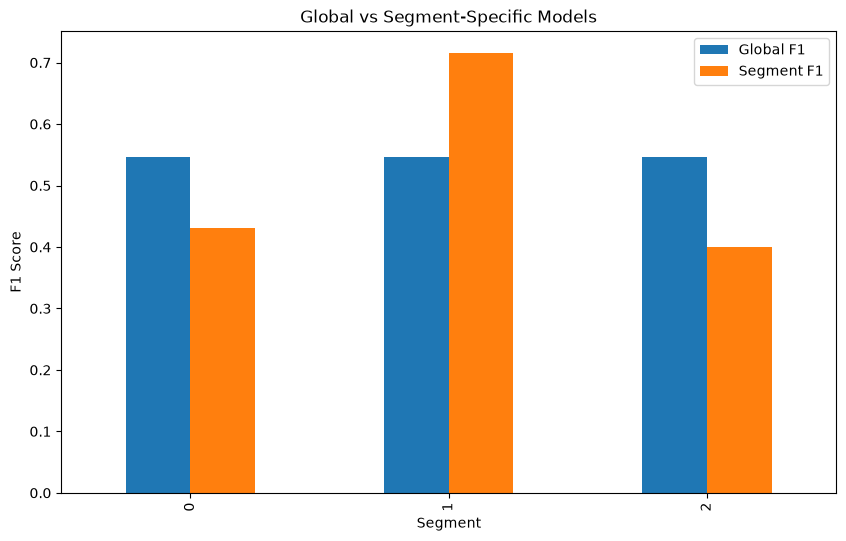

In [86]:
comparison_df.plot(
    x='Segment',
    y=['Global F1','Segment F1'],
    kind='bar',
    figsize=(10,6)
)

plt.title(
    'Global vs Segment-Specific Models'
)

plt.ylabel('F1 Score')

plt.show()

In [87]:
comparison_df.sort_values(
    by='F1 Improvement',
    ascending=False
)

,Segment,Global Accuracy,Segment Accuracy,Global F1,Segment F1,Global AUC,Segment AUC,Accuracy Improvement,F1 Improvement,AUC Improvement
1,1,0.644578,0.616915,0.546154,0.715867,0.705718,0.601421,-0.027663,0.169713,-0.104297
0,0,0.644578,0.636591,0.546154,0.431373,0.705718,0.678061,-0.007987,-0.114781,-0.027657
2,2,0.644578,0.950000,0.546154,0.400000,0.705718,0.698830,0.305422,-0.146154,-0.006888


In [88]:
import shap

In [89]:
explainer = shap.TreeExplainer(rf_global)

shap_values = explainer.shap_values(X_test)

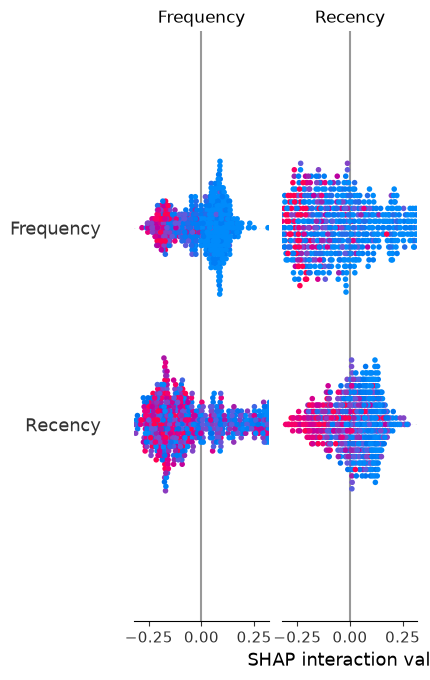

In [90]:
shap.summary_plot(
    shap_values,
    X_test
)

In [91]:
segment0 = rfm[rfm['Segment']==0]

X0 = segment0[
    ['Recency','Frequency','Monetary']
]

y0 = segment0['Churn']

In [92]:
rf0 = RandomForestClassifier(
    random_state=42
)

rf0.fit(X0,y0)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

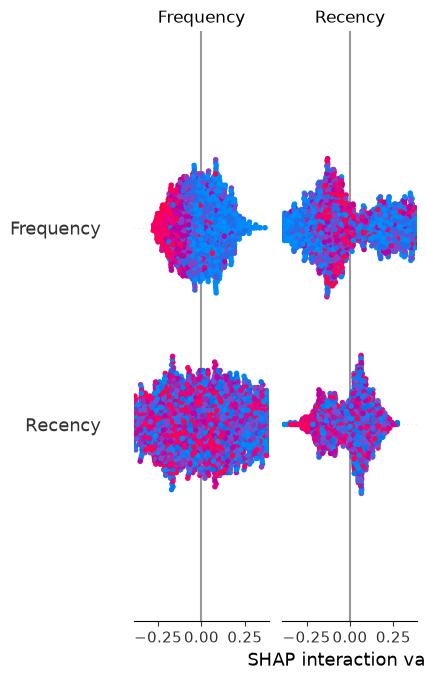

In [93]:
explainer0 = shap.TreeExplainer(rf0)

shap_values0 = explainer0.shap_values(X0)

shap.summary_plot(
    shap_values0,
    X0
)

In [94]:
comparison_df

,Segment,Global Accuracy,Segment Accuracy,Global F1,Segment F1,Global AUC,Segment AUC,Accuracy Improvement,F1 Improvement,AUC Improvement
0,0,0.644578,0.636591,0.546154,0.431373,0.705718,0.678061,-0.007987,-0.114781,-0.027657
1,1,0.644578,0.616915,0.546154,0.715867,0.705718,0.601421,-0.027663,0.169713,-0.104297
2,2,0.644578,0.950000,0.546154,0.400000,0.705718,0.698830,0.305422,-0.146154,-0.006888


In [95]:
comparison_df.sort_values(
    by='F1 Improvement',
    ascending=False
)

,Segment,Global Accuracy,Segment Accuracy,Global F1,Segment F1,Global AUC,Segment AUC,Accuracy Improvement,F1 Improvement,AUC Improvement
1,1,0.644578,0.616915,0.546154,0.715867,0.705718,0.601421,-0.027663,0.169713,-0.104297
0,0,0.644578,0.636591,0.546154,0.431373,0.705718,0.678061,-0.007987,-0.114781,-0.027657
2,2,0.644578,0.950000,0.546154,0.400000,0.705718,0.698830,0.305422,-0.146154,-0.006888


In [96]:
segment_profile = rfm.groupby('Segment')[
    ['Recency','Frequency','Monetary']
].mean()

segment_profile

,Recency,Frequency,Monetary
Segment,,,
0,53.994483,2.697593,953.192408
1,193.343284,1.382090,444.481522
2,21.699324,12.263514,5593.633885
3,19.863636,46.136364,56188.879091


Segment 0 = Loyal Customers
Segment 1 = Occasional Customers
Segment 2 = High Value Customers
Segment 3 = At Risk Customers

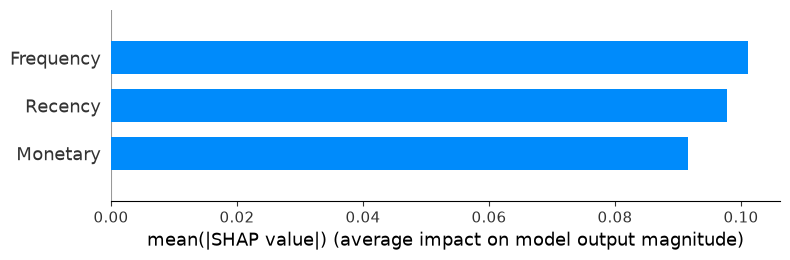

In [97]:
shap.summary_plot(
    shap_values[:,:,1],
    X_test,
    plot_type="bar"
)

In [98]:
segment0 = rfm[rfm['Segment'] == 0]

X0 = segment0[
    ['Recency','Frequency','Monetary']
]

y0 = segment0['Churn']

In [99]:
from sklearn.ensemble import RandomForestClassifier

rf0 = RandomForestClassifier(
    random_state=42
)

rf0.fit(X0,y0)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [100]:
explainer0 = shap.TreeExplainer(rf0)

shap_values0 = explainer0.shap_values(X0)

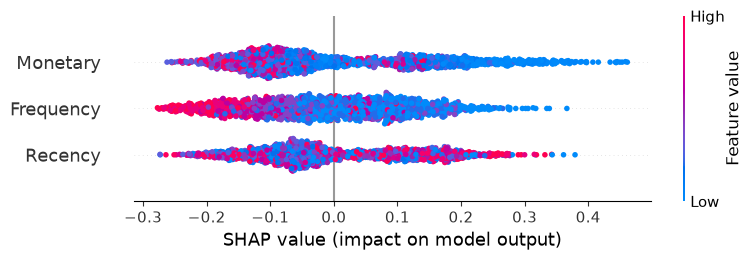

In [101]:
shap.summary_plot(
    shap_values0[:,:,1],
    X0
)

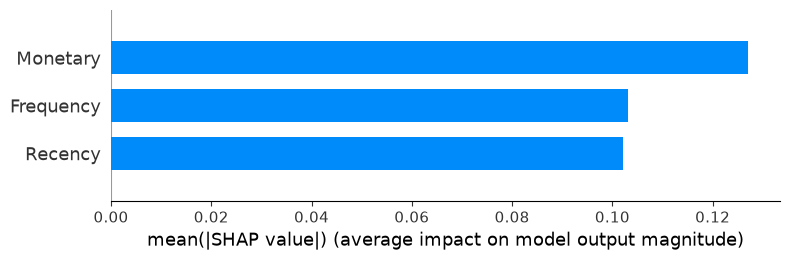

In [102]:
shap.summary_plot(
    shap_values0[:,:,1],
    X0,
    plot_type='bar'
)


Segment 0


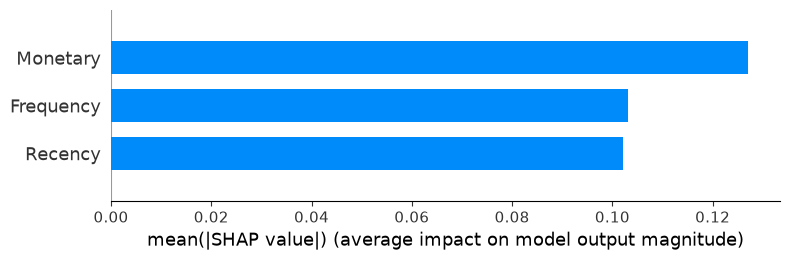


Segment 1


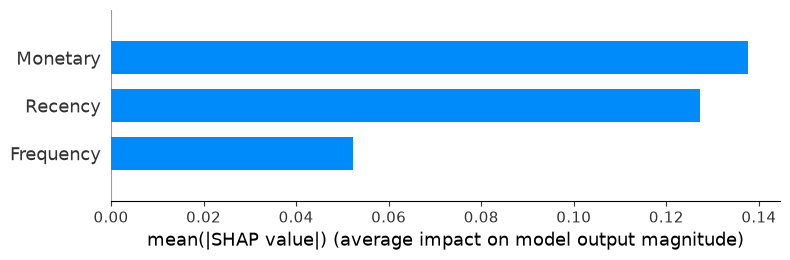


Segment 2


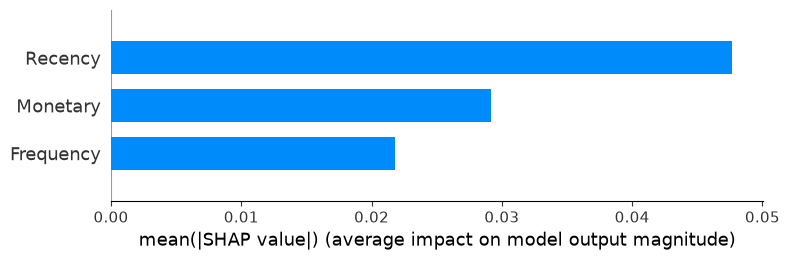


Segment 3


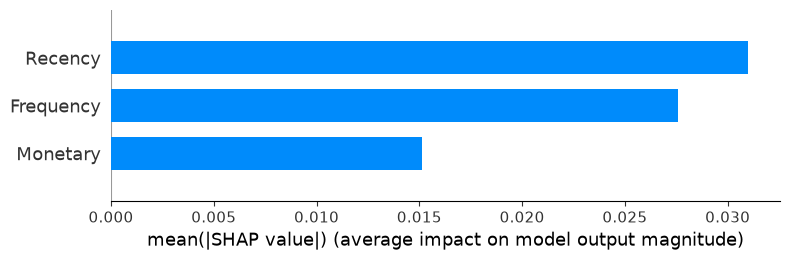

In [103]:
for segment in sorted(rfm['Segment'].unique()):

    segment_data = rfm[rfm['Segment']==segment]

    if segment_data['Churn'].nunique() < 2:
        continue

    X_seg = segment_data[
        ['Recency','Frequency','Monetary']
    ]

    y_seg = segment_data['Churn']

    rf = RandomForestClassifier(
        random_state=42
    )

    rf.fit(X_seg,y_seg)

    explainer = shap.TreeExplainer(rf)

    shap_values = explainer.shap_values(X_seg)

    print(f"\nSegment {segment}")

    shap.summary_plot(
        shap_values[:,:,1],
        X_seg,
        plot_type='bar'
    )

In [104]:
comparison_df.sort_values(
    by='F1 Improvement',
    ascending=False
)

,Segment,Global Accuracy,Segment Accuracy,Global F1,Segment F1,Global AUC,Segment AUC,Accuracy Improvement,F1 Improvement,AUC Improvement
1,1,0.644578,0.616915,0.546154,0.715867,0.705718,0.601421,-0.027663,0.169713,-0.104297
0,0,0.644578,0.636591,0.546154,0.431373,0.705718,0.678061,-0.007987,-0.114781,-0.027657
2,2,0.644578,0.950000,0.546154,0.400000,0.705718,0.698830,0.305422,-0.146154,-0.006888


In [105]:
rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Segment,,,
0,53.994483,2.697593,953.192408
1,193.343284,1.382090,444.481522
2,21.699324,12.263514,5593.633885
3,19.863636,46.136364,56188.879091


In [49]:
recency = df.groupby('CustomerID')['InvoiceDate'].max()

recency = (max_date - recency).dt.days

In [50]:
print(recency)

CustomerID
12346    325
12347      1
12348     74
12349     18
12350    309
        ... 
18280    277
18281    180
18282      7
18283      3
18287     42
Name: InvoiceDate, Length: 4338, dtype: int64


In [51]:
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

In [52]:
print(frequency)

CustomerID
12346     1
12347     7
12348     4
12349     1
12350     1
         ..
18280     1
18281     1
18282     2
18283    16
18287     3
Name: InvoiceNo, Length: 4338, dtype: int64


In [53]:
monetary = df.groupby('CustomerID')['Revenue'].sum()

In [54]:
print(monetary)

CustomerID
12346    77183.60
12347     4310.00
12348     1797.24
12349     1757.55
12350      334.40
           ...   
18280      180.60
18281       80.82
18282      178.05
18283     2094.88
18287     1837.28
Name: Revenue, Length: 4338, dtype: float64


In [55]:
rfm = pd.DataFrame()
rfm['Recency'] = recency
rfm['Frequency'] = frequency
rfm['Monetary'] = monetary
rfm.head(5)

,Recency,Frequency,Monetary
CustomerID,,,
12346,325,1,77183.60
12347,1,7,4310.00
12348,74,4,1797.24
12349,18,1,1757.55
12350,309,1,334.40


In [56]:
avg_order_value = monetary / frequency

rfm['AvgOrderValue'] = avg_order_value
print(rfm)

            Recency  Frequency  Monetary  AvgOrderValue
CustomerID                                             
12346           325          1  77183.60   77183.600000
12347             1          7   4310.00     615.714286
12348            74          4   1797.24     449.310000
12349            18          1   1757.55    1757.550000
12350           309          1    334.40     334.400000
...             ...        ...       ...            ...
18280           277          1    180.60     180.600000
18281           180          1     80.82      80.820000
18282             7          2    178.05      89.025000
18283             3         16   2094.88     130.930000
18287            42          3   1837.28     612.426667

[4338 rows x 4 columns]


In [57]:
total_quantity = df.groupby('CustomerID')['Quantity'].sum()

rfm['TotalQuantity'] = total_quantity

In [58]:
unique_products = df.groupby('CustomerID')['StockCode'].nunique()

rfm['UniqueProducts'] = unique_products

In [59]:
print(rfm)

            Recency  Frequency  Monetary  AvgOrderValue  TotalQuantity  \
CustomerID                                                               
12346           325          1  77183.60   77183.600000          74215   
12347             1          7   4310.00     615.714286           2458   
12348            74          4   1797.24     449.310000           2341   
12349            18          1   1757.55    1757.550000            631   
12350           309          1    334.40     334.400000            197   
...             ...        ...       ...            ...            ...   
18280           277          1    180.60     180.600000             45   
18281           180          1     80.82      80.820000             54   
18282             7          2    178.05      89.025000            103   
18283             3         16   2094.88     130.930000           1397   
18287            42          3   1837.28     612.426667           1586   

            UniqueProducts  
Customer

In [60]:
print(df[df['CustomerID'] == 12347]['StockCode'].nunique())

103
